# Merge duplicate junction pairs

NWB creates duplicate junctions in two distinct situations, both of which this notebook resolves:

**1. Dual-carriageway duplicates (FOW=2)**  
Divided roads (FOW=2) are stored as two separate wegvakken. Where such a road crosses another
road, NWB creates 2 junctions instead of 1, typically 10â€“30m apart.  
Detection: at least one junction in the pair must have a FOW=2 connection.

**2. Bayonet intersections**  
A single physical junction is sometimes digitised as two separate nodes placed very close together
(â‰¤6m), even on single-carriageway roads. The 6m threshold is grounded in NWB road geometry:
a typical Dutch road is ~3m wide, so two adjacent carriageway centrelines sit ~6m apart.  
Detection: pure proximity â€” no FOW filter needed, as real distinct intersections are never this close.

**Pipeline:**
1. Identify junctions touched by at least one FOW=2 segment (dual-carriageway signal)
2. Find junction pairs within 30m where at least one junction has a FOW=2 connection
3. Find junction pairs within 6m regardless of FOW (bayonet signal)
4. Take the union of both candidate sets
5. Resolve transitive chains (Aâ€“B and Bâ€“C â†’ merge all three) via connected components
6. Merge each cluster: centroid geometry, canonical JTE_ID
7. Update `wegvakken` endpoint columns (`JTE_ID_BEG`, `JTE_ID_END`) to point to canonical IDs
8. Drop self-loop segments (now Aâ†’A after remapping), recompute `street_count`, filter to â‰¥3
9. Save merged outputs

## 0. Setup

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from shapely.geometry import Point
from scipy.spatial import cKDTree
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

# --- Paths ---
PROJECT_DIR = r"C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second_year\Afstuderen\Project\intersections"

WEGVAKKEN_ROT_PATH = os.path.join(PROJECT_DIR, "data", "processed", "wegvakken_rotterdam.gpkg")
WEGVAKKEN_BST_PATH = os.path.join(PROJECT_DIR, "data", "processed", "wegvakken_rotterdam_bst.gpkg")
WEGVAKKEN_NL_PATH  = os.path.join(PROJECT_DIR, "data", "raw", "Wegvakken.gpkg")
INTERSECTIONS_PATH = os.path.join(PROJECT_DIR, "data", "processed", "intersections.gpkg")

# Output paths for the merged dataset
OUT_INTERSECTIONS = os.path.join(PROJECT_DIR, "data", "processed", "intersections_merged.gpkg")
OUT_WEGVAKKEN     = os.path.join(PROJECT_DIR, "data", "processed", "wegvakken_rotterdam_bst_merged.gpkg")

# Rotterdam boundary
BOUNDARY_PATH = os.path.join(PROJECT_DIR, "data", "processed", "Rotterdam_boundary.gpkg")

CRS_RD       = "EPSG:28992"  # RD New
INCLUDE_BST  = {"RB", "ERF", "HR"}

# --- Merge thresholds ---
MERGE_THRESHOLD   = 25  # metres
BAYONET_THRESHOLD =  6  # metres

# --- Photo capture distances (shared with notebooks 02 and 04) ---
# Imported from pipeline_config.py — change values there, then re-run this notebook
# to recompute max_dist_m / ideal_dist_m in intersections_merged.gpkg.
# Notebooks 02 and 04 read those columns from the file and pick up the new values automatically.
_config_dir = os.path.join(PROJECT_DIR, "notebooks", "pipeline")
if _config_dir not in sys.path:
    sys.path.insert(0, _config_dir)
from pipeline_config import (
    CAPTURE_BUFFER_M,          # buffer above ideal_dist_m; max_dist_m = ideal_dist_m + this
    IDEAL_PHOTO_DIST_BASE,     # base ideal shot distance for singletons (radius=0)
    IDEAL_DIST_RADIUS_FACTOR,  # ideal_dist_m = BASE + cluster_radius * FACTOR
)
print(f"CAPTURE_BUFFER_M={CAPTURE_BUFFER_M}m  |  ideal formula: {IDEAL_PHOTO_DIST_BASE} + radius × {IDEAL_DIST_RADIUS_FACTOR:.3f}")

CAPTURE_BUFFER_M=5m  |  ideal formula: 20 + radius × 0.500


## 1. Load data

In [2]:
# Load road segments at two filter levels:
#   wegvakken          — gemeente-managed + BST filter: the pipeline working dataset
#   wegvakken_gemeente — gemeente-managed only (no BST filter): used for road-network
#                        visualisations so roundabout outlines and all road types are
#                        visible as background context. NOT needed for FOW=2 detection
#                        — FOW=2 roads have BST_CODE=RB/HR and survive the BST filter.

if os.path.exists(WEGVAKKEN_ROT_PATH) and os.path.exists(WEGVAKKEN_BST_PATH):
    print("Loading preprocessed Rotterdam files ...")
    wegvakken_rot = gpd.read_file(WEGVAKKEN_ROT_PATH)
    wegvakken     = gpd.read_file(WEGVAKKEN_BST_PATH)
else:
    print("Preprocessed files not found — loading national file (slow) ...")
    wegvakken_nl  = gpd.read_file(WEGVAKKEN_NL_PATH)
    wegvakken_rot = wegvakken_nl[wegvakken_nl["GME_NAAM"] == "Rotterdam"].copy()
    del wegvakken_nl
    wegvakken = wegvakken_rot[wegvakken_rot["WEGBEHSRT"] == "G"].copy()
    wegvakken = wegvakken[wegvakken["BST_CODE"].isin(INCLUDE_BST)].copy()

# Gemeente roads without BST filter — used only as visual background in plots
# (shows roundabout outlines, slip roads etc. for spatial context)
wegvakken_gemeente = wegvakken_rot[wegvakken_rot["WEGBEHSRT"] == "G"].copy()

# Load pipeline intersections (junctions with street_count >= 3, indexed by JTE_ID)
intersections = gpd.read_file(INTERSECTIONS_PATH).set_index("JTE_ID")

# Clip intersections to the Rotterdam boundary immediately.
# Some junctions near the city edge fall just outside the boundary polygon —
# removing them here keeps all downstream counts (FOW=2 detection, pair finding,
# merge stats) consistent with the actual study area.
rotterdam = gpd.read_file(BOUNDARY_PATH)
rotterdam_polygon = rotterdam.geometry.union_all()  # dissolve to a single polygon
n_before = len(intersections)
intersections = intersections[intersections.geometry.within(rotterdam_polygon)].copy()

print(f"wegvakken_gemeente: {len(wegvakken_gemeente):,} segments (visualisation only)")
print(f"wegvakken (BST):    {len(wegvakken):,} segments")
print(f"intersections:      {len(intersections):,} junctions  ({n_before - len(intersections):,} outside boundary removed)")

Loading preprocessed Rotterdam files ...


wegvakken_gemeente: 38,292 segments (visualisation only)
wegvakken (BST):    25,881 segments
intersections:      5,690 junctions  (156 outside boundary removed)


## 2. Identify FOW=2 junction endpoints

For each junction in the pipeline `intersections`, check whether any connected segment
(in `wegvakken_gemeente`, which includes FOW=2 roads) has `FOW=2`.
This gives us the dual-carriageway signal.

In [3]:
# We can use the BST-filtered `wegvakken` directly â€” no need for the unfiltered
# wegvakken_gemeente here.
wvk_g = wegvakken[["JTE_ID_BEG", "JTE_ID_END", "FOW"]].copy()
wvk_g["FOW_int"] = pd.to_numeric(wvk_g["FOW"], errors="coerce")

# Build long-form table: one row per (junction_id, FOW_of_connected_segment)
jte_fow = pd.concat([
    wvk_g[["JTE_ID_BEG", "FOW_int"]].rename(columns={"JTE_ID_BEG": "JTE_ID"}),
    wvk_g[["JTE_ID_END", "FOW_int"]].rename(columns={"JTE_ID_END": "JTE_ID"}),
], ignore_index=True)

# Count how many FOW=2 segments connect to each junction.
# Require >=2: a true dual-carriageway junction sits on two parallel FOW=2 wegvakken
# (one per direction), so count>=2 is the correct signal. A junction with only 1
# FOW=2 connection is at the fringe of a dual-carriageway section and should not
# trigger the merge signal on its own.
fow2_count   = jte_fow.groupby("JTE_ID")["FOW_int"].apply(lambda x: (x == 2).sum())
has_fow2     = fow2_count >= 2

# Align to our pipeline intersections index
fow2_flag    = has_fow2.reindex(intersections.index).fillna(False)

# Set of JTE_IDs with >=2 FOW=2 connections â€” used to filter proximity pairs later
fow2_jte_set = set(fow2_flag[fow2_flag].index)

print(f"Pipeline intersections with â‰¥2 FOW=2 connections: {fow2_flag.sum():,} / {len(intersections):,}")
print(f"({fow2_flag.mean()*100:.1f}% of all pipeline intersections)")


Pipeline intersections with â‰¥2 FOW=2 connections: 2,094 / 5,690
(36.8% of all pipeline intersections)


## 3. Find close junction pairs (proximity signal)

Use a KD-tree to efficiently find all pairs of pipeline intersections within the relevant thresholds.
Two detection signals are combined into one candidate set:

1. **FOW=2 signal** (25m threshold): pairs where at least one junction has a FOW=2 connection.
   Catches physically separated dual-carriageway roads that NWB splits into two junctions.
2. **Bayonet signal** (7m threshold): pairs within 7m regardless of FOW.
   Catches **bayonet intersections** â€” NWB digitisation artefacts where a single physical junction
   is stored as two near-identical nodes. The 7m threshold follows from the ~3m width of a typical
   Dutch road: the centrelines of two adjacent lanes sit roughly 7m apart, so anything closer is
   almost certainly the same real-world junction. No FOW filter is needed here.

The union of both sets is passed to the connected-components step.

In [4]:
# Extract (x, y) coordinates for all pipeline intersections.
# CRS is RD New (metres), so distances from KD-tree are in metres directly.
inter_ids    = np.array(intersections.index)  # JTE_ID values, same order as coords
inter_coords = np.array([(geom.x, geom.y) for geom in intersections.geometry])

# Build KD-tree once â€” reused for both distance thresholds below.
tree = cKDTree(inter_coords)

# --- Signal 1: FOW=2 pairs (30m threshold) ---
# Find all pairs within the merge threshold, then keep only those where
# at least one junction has a FOW=2 connection. This avoids merging
# close-but-distinct intersections on single-carriageway roads.
pairs_30m  = tree.query_pairs(r=MERGE_THRESHOLD)
fow2_pairs = {
    (inter_ids[i], inter_ids[j])
    for i, j in pairs_30m
    if inter_ids[i] in fow2_jte_set or inter_ids[j] in fow2_jte_set
}

print(f"Total junction pairs within {MERGE_THRESHOLD}m:          {len(pairs_30m):,}")
print(f"  â†’ kept (â‰¥1 FOW=2 connection):                 {len(fow2_pairs):,}")
print(f"  â†’ filtered out (no FOW=2, not merged):        {len(pairs_30m) - len(fow2_pairs):,}")

# --- Signal 2: Tight proximity pairs / bayonet (6m threshold, no FOW filter) ---
# Junctions within 6m of each other are almost certainly the same physical
# point split by NWB (bayonet intersections). The 6m threshold is grounded in
# NWB road geometry: a typical Dutch road is ~3m wide, so two adjacent carriageway
# centrelines sit ~6m apart. No FOW filter is applied because genuine distinct
# intersections are never this close together.
pairs_bay     = tree.query_pairs(r=BAYONET_THRESHOLD)
bayonet_pairs = {
    (inter_ids[i], inter_ids[j])
    for i, j in pairs_bay
}

print(f"\nTotal junction pairs within {BAYONET_THRESHOLD}m (bayonet):  {len(pairs_bay):,}")
print(f"  â†’ all kept (no FOW filter needed at this distance): {len(bayonet_pairs):,}")

# --- Union: combine both signals into one candidate set ---
# Store as frozensets so we can deduplicate; also track which signal(s) triggered each pair.
all_merge_pairs = list(fow2_pairs | bayonet_pairs)

# Tag each pair with its signal source â€” used in the verification section
overlap_pairs  = fow2_pairs & bayonet_pairs
only_fow2      = fow2_pairs - bayonet_pairs
only_bayonet   = bayonet_pairs - fow2_pairs

print(f"\nTotal unique merge candidates (union):  {len(all_merge_pairs):,}")
print(f"  FOW=2 only:       {len(only_fow2):,}")
print(f"  Bayonet only:     {len(only_bayonet):,}")
print(f"  Both signals:     {len(overlap_pairs):,}")

Total junction pairs within 25m:          1,742
  â†’ kept (â‰¥1 FOW=2 connection):                 1,290
  â†’ filtered out (no FOW=2, not merged):        452

Total junction pairs within 6m (bayonet):  72
  â†’ all kept (no FOW filter needed at this distance): 72

Total unique merge candidates (union):  1,308
  FOW=2 only:       1,236
  Bayonet only:     18
  Both signals:     54


## 4. Resolve transitive chains â†’ merge clusters

A single physical intersection can involve more than 2 junctions (e.g. dual Ã— dual = 4 junctions).
Pairs (A,B) and (B,C) should all merge together, not independently.

We use **connected components** on a sparse graph of the pairs to resolve transitivity:
all junctions in one connected component form a single merge cluster.

In [5]:
# Map JTE_IDs to sequential integers (0..N-1) for the sparse matrix
n = len(intersections)
id_to_idx = {jte_id: idx for idx, jte_id in enumerate(inter_ids)}

# Build a symmetric sparse adjacency matrix from the merge-candidate pairs
if all_merge_pairs:
    rows = [id_to_idx[a] for a, b in all_merge_pairs] + [id_to_idx[b] for a, b in all_merge_pairs]
    cols = [id_to_idx[b] for a, b in all_merge_pairs] + [id_to_idx[a] for a, b in all_merge_pairs]
    data = np.ones(len(rows), dtype=np.int8)
    adj  = csr_matrix((data, (rows, cols)), shape=(n, n))
else:
    adj  = csr_matrix((n, n), dtype=np.int8)

# Find connected components â€” each component is one logical intersection
n_components, labels = connected_components(adj, directed=False)

# Count how many junctions land in multi-member components (i.e. will be merged)
label_counts  = pd.Series(labels).value_counts()
multi_labels  = label_counts[label_counts > 1]  # components with â‰¥2 members
n_merged_from = (labels[:, None] == multi_labels.index.values).any(axis=1).sum()

print(f"Connected components total:          {n_components:,}")
print(f"  Multi-junction components (merged): {len(multi_labels):,}")
print(f"  Singleton components (unchanged):   {n_components - len(multi_labels):,}")
print(f"Junctions participating in a merge:  {n_merged_from:,} â†’ {len(multi_labels):,} logical intersections")
print(f"Net reduction: {n_merged_from - len(multi_labels):,} junctions removed")

Connected components total:          4,736
  Multi-junction components (merged): 600
  Singleton components (unchanged):   4,136
Junctions participating in a merge:  1,554 â†’ 600 logical intersections
Net reduction: 954 junctions removed


In [6]:
# Build the remap dict: non-canonical JTE_ID â†’ canonical JTE_ID.
# Canonical = the numerically smallest JTE_ID in each cluster (arbitrary but stable).
#
# Also build the merged geometry: centroid of all cluster members' points.

remap          = {}   # old_jte_id â†’ canonical_jte_id  (only for non-canonical members)
merged_geoms   = {}   # canonical_jte_id â†’ merged Point geometry

for comp_label in multi_labels.index:
    # Indices (into inter_ids / inter_coords) belonging to this component
    member_mask    = labels == comp_label
    member_jte_ids = inter_ids[member_mask]  # JTE_IDs in this cluster
    member_coords  = inter_coords[member_mask]  # their (x, y) coordinates

    # Pick canonical ID as the smallest JTE_ID in the cluster
    canonical_id   = int(member_jte_ids.min())

    # Centroid of all cluster members becomes the new geometry
    centroid_x, centroid_y = member_coords.mean(axis=0)
    merged_geoms[canonical_id] = Point(centroid_x, centroid_y)

    # All non-canonical members get remapped to the canonical ID
    for jte_id in member_jte_ids:
        if int(jte_id) != canonical_id:
            remap[int(jte_id)] = canonical_id

print(f"Remap dict entries (junctions to redirect): {len(remap):,}")
print(f"New centroid geometries computed:           {len(merged_geoms):,}")

# Sanity check: no canonical ID should itself appear as a key in remap
assert not (set(remap.values()) & set(remap.keys())), "Canonical IDs must not be remapped"

Remap dict entries (junctions to redirect): 954
New centroid geometries computed:           600


## 5. Merge junctions

Apply the remap to `intersections`:
- Drop all non-canonical junctions (the ones being absorbed)
- Update the canonical junctions' geometry to the cluster centroid

In [7]:
# Work on a copy so the original is preserved for comparison
intersections_merged = intersections.copy()

# Remove non-canonical junctions (they are absorbed into their canonical junction)
intersections_merged = intersections_merged.drop(index=list(remap.keys()), errors="ignore")

# Update geometry of canonical junctions to the centroid of their cluster
# (only canonical IDs that were part of a multi-junction cluster have a new geometry)
for canonical_id, new_geom in merged_geoms.items():
    if canonical_id in intersections_merged.index:
        intersections_merged.at[canonical_id, "geometry"] = new_geom

print(f"intersections (before): {len(intersections):,}")
print(f"intersections (after):  {len(intersections_merged):,}")
print(f"Net reduction:          {len(intersections) - len(intersections_merged):,}")

intersections (before): 5,690
intersections (after):  4,736
Net reduction:          954


## 6. Update wegvakken endpoints + drop self-loops

After remapping junction IDs, any segment whose two endpoints were in the same merge cluster
becomes a self-loop (both endpoints now point to the same canonical ID). This applies to:

- **Dual-carriageway connectors**: the short segment physically linking the two parallel carriageways.
- **Bayonet connectors**: the tiny segment between two near-identical nodes.

In both cases the segment no longer represents a real traversable road in the logical graph,
so self-loops are dropped entirely.

In [8]:
# Work on a copy of the BST-filtered pipeline dataset
wegvakken_merged = wegvakken.copy()

n_before = len(wegvakken_merged)

# Replace any absorbed (non-canonical) JTE_IDs with their canonical equivalent.
# .map() returns NaN where the key is not in the remap dict, so we use .fillna()
# to keep the original value for IDs that don't need remapping.
wegvakken_merged["JTE_ID_BEG"] = (
    wegvakken_merged["JTE_ID_BEG"]
    .map(remap)
    .fillna(wegvakken_merged["JTE_ID_BEG"])
    .astype(wegvakken["JTE_ID_BEG"].dtype)  # preserve original dtype
)
wegvakken_merged["JTE_ID_END"] = (
    wegvakken_merged["JTE_ID_END"]
    .map(remap)
    .fillna(wegvakken_merged["JTE_ID_END"])
    .astype(wegvakken["JTE_ID_END"].dtype)
)

# Drop self-loops: segments where both endpoints now refer to the same canonical junction.
# These were the short connector roads between the two carriageways of a divided road.
self_loop_mask   = wegvakken_merged["JTE_ID_BEG"] == wegvakken_merged["JTE_ID_END"]
wegvakken_merged = wegvakken_merged[~self_loop_mask].copy()

print(f"wegvakken (before): {n_before:,} segments")
print(f"Self-loops removed: {self_loop_mask.sum():,}")
print(f"wegvakken (after):  {len(wegvakken_merged):,} segments")

wegvakken (before): 25,881 segments
Self-loops removed: 1,044
wegvakken (after):  24,837 segments


## 7. Recompute street_count and rebuild intersections

After updating the wegvakken endpoints, the `street_count` per junction must be recomputed
from scratch â€” some canonical junctions now have more connections (they absorbed their twin's
connections), and any junction whose count dropped below 3 is no longer a real intersection.

In [9]:
# Count how many wegvakken reference each JTE_ID (after remapping + self-loop removal)
# Using the merged pipeline dataset (BST-filtered) â€” consistent with the original pipeline.

# Long-form: one row per (junction, segment) connection
jte_refs = pd.concat([
    wegvakken_merged["JTE_ID_BEG"],
    wegvakken_merged["JTE_ID_END"],
], ignore_index=True)

street_count_new = jte_refs.value_counts().rename("street_count")

# Apply updated street counts back to intersections_merged
intersections_merged["street_count"] = street_count_new.reindex(intersections_merged.index)

# Drop any junction whose street_count is now < 3 (dead ends or degree-2 nodes)
# This can happen if a self-loop removal reduces connectivity.
valid_mask           = intersections_merged["street_count"] >= 3
intersections_merged = intersections_merged[valid_mask].copy()

print(f"intersections (before recount): {len(intersections_merged) + (~valid_mask).sum():,}")
print(f"Junctions dropped (count < 3):  {(~valid_mask).sum():,}")
print(f"intersections (final):          {len(intersections_merged):,}")
print(f"\nstreet_count distribution (merged intersections):")
print(intersections_merged["street_count"].value_counts().sort_index().to_frame())

intersections (before recount): 4,736
Junctions dropped (count < 3):  21
intersections (final):          4,715

street_count distribution (merged intersections):
              count
street_count       
3.0            3464
4.0             731
5.0             192
6.0             211
7.0              45
8.0              48
9.0              10
10.0              2
11.0              8
12.0              2
13.0              1
14.0              1


In [10]:
from itertools import combinations

# Compute cluster diameter and size for every logical intersection.
# diameter_m = max straight-line distance between any two original member points.
# Singletons have size=1 and diameter=0 by definition.

cluster_size_map = {}  # canonical_id -> number of original junctions in cluster
diameter_map     = {}  # canonical_id -> max pairwise distance between members (metres)

# Iterate over ALL components (singletons + multi-junction clusters)
for comp_label, size in pd.Series(labels).value_counts().items():
    member_mask    = labels == comp_label
    member_jte_ids = inter_ids[member_mask]
    member_coords  = inter_coords[member_mask]

    # Canonical ID = smallest JTE_ID in the cluster (same convention as remap)
    canonical_id = int(member_jte_ids.min())

    cluster_size_map[canonical_id] = int(size)

    # Diameter: max pairwise distance; 0 for singletons
    if size == 1:
        diameter_map[canonical_id] = 0.0
    else:
        diameter_map[canonical_id] = max(
            np.linalg.norm(member_coords[i] - member_coords[j])
            for i, j in combinations(range(size), 2)
        )

# Attach to intersections_merged (only canonical IDs present after merging)
intersections_merged["cluster_size"] = (
    pd.Series(cluster_size_map).reindex(intersections_merged.index).fillna(1).astype(int)
)
intersections_merged["diameter_m"] = (
    pd.Series(diameter_map).reindex(intersections_merged.index).fillna(0.0)
)

# Compute per-intersection ideal shot distance and outer search radius.
# cluster_radius = diameter_m / 2
#
# ideal_dist_m = IDEAL_PHOTO_DIST_BASE + cluster_radius * IDEAL_DIST_RADIUS_FACTOR
#   — singletons (radius=0) get exactly IDEAL_PHOTO_DIST_BASE metres
#   — larger clusters push the ideal outward, but more gently (factor < 1)
# max_dist_m   = ideal_dist_m + CAPTURE_BUFFER_M  (fixed buffer above the ideal)
#   — always CAPTURE_BUFFER_M metres beyond ideal, regardless of cluster size
# Change these constants in pipeline_config.py and re-run to tune.
intersections_merged["ideal_dist_m"] = (
    IDEAL_PHOTO_DIST_BASE + intersections_merged["diameter_m"] / 2 * IDEAL_DIST_RADIUS_FACTOR
).round(1)
intersections_merged["max_dist_m"] = (
    intersections_merged["ideal_dist_m"] + CAPTURE_BUFFER_M
).round(1)

print("Cluster size distribution:")
print(intersections_merged["cluster_size"].value_counts().sort_index().to_frame())
print(f"max_dist_m:   {intersections_merged['max_dist_m'].min():.1f} to {intersections_merged['max_dist_m'].max():.1f} m")
print(f"ideal_dist_m: {intersections_merged['ideal_dist_m'].min():.1f} to {intersections_merged['ideal_dist_m'].max():.1f} m")

Cluster size distribution:
              count
cluster_size       
1              4116
2               408
3                87
4                70
5                20
6                 7
7                 3
8                 4
max_dist_m:   25.0 to 40.9 m
ideal_dist_m: 20.0 to 35.9 m


## 8. Save outputs

In [11]:
# Reset index so JTE_ID becomes a regular column (gpkg format requires a column, not an index)
intersections_out = intersections_merged.reset_index()  # JTE_ID back as column

intersections_out.to_file(OUT_INTERSECTIONS, driver="GPKG")
wegvakken_merged.to_file(OUT_WEGVAKKEN, driver="GPKG")

print(f"Saved {len(intersections_out):,} intersections â†’ {OUT_INTERSECTIONS}")
print(f"Saved {len(wegvakken_merged):,} wegvakken      â†’ {OUT_WEGVAKKEN}")
print()
print("To use these in the pipeline, update the INTERSECTIONS_PATH and WEGVAKKEN_BST_PATH")
print("in notebooks 02, 04, and 05 to point to the merged files.")

Saved 4,715 intersections â†’ C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second_year\Afstuderen\Project\intersections\data\processed\intersections_merged.gpkg
Saved 24,837 wegvakken      â†’ C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second_year\Afstuderen\Project\intersections\data\processed\wegvakken_rotterdam_bst_merged.gpkg

To use these in the pipeline, update the INTERSECTIONS_PATH and WEGVAKKEN_BST_PATH
in notebooks 02, 04, and 05 to point to the merged files.


## 9. Verification

Visual and numeric check: compare before/after at a few example locations.

In [12]:
# Summary statistics: how much did the dataset change?
print("=== Merge summary ===")
print(f"Junctions before: {len(intersections):,}")
print(f"Junctions after:  {len(intersections_merged):,}")
print(f"Reduction:        {len(intersections) - len(intersections_merged):,} ({(1 - len(intersections_merged)/len(intersections))*100:.1f}%)")
print()
print(f"Wegvakken before: {len(wegvakken):,}")
print(f"Wegvakken after:  {len(wegvakken_merged):,}")
print(f"Reduction:        {len(wegvakken) - len(wegvakken_merged):,} (self-loops removed)")
print()
print(f"Merge clusters created: {len(multi_labels):,}")
print(f"  of which 2-junction merges: {(multi_labels == 2).sum():,}")
print(f"  of which 3-junction merges: {(multi_labels == 3).sum():,}")
print(f"  of which 4+ junction merges: {(multi_labels >= 4).sum():,}")

=== Merge summary ===
Junctions before: 5,690
Junctions after:  4,715
Reduction:        975 (17.1%)

Wegvakken before: 25,881
Wegvakken after:  24,837
Reduction:        1,044 (self-loops removed)

Merge clusters created: 600
  of which 2-junction merges: 409
  of which 3-junction merges: 87
  of which 4+ junction merges: 104


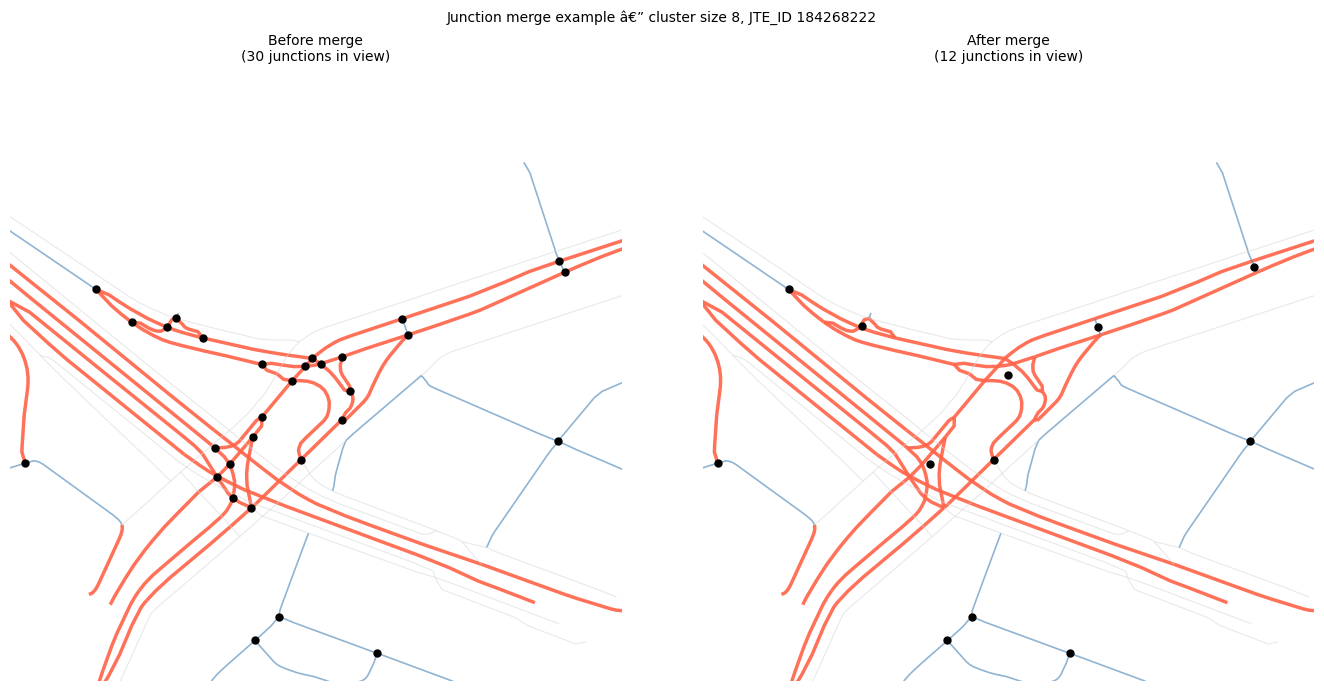

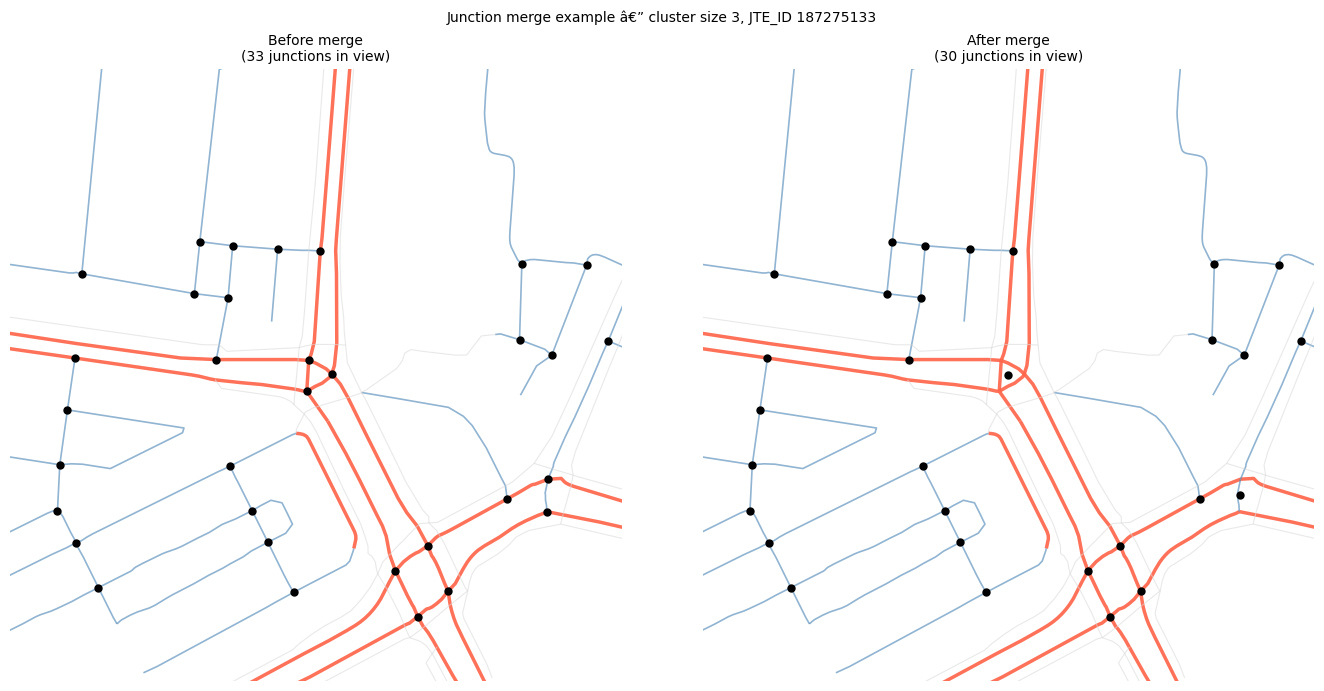

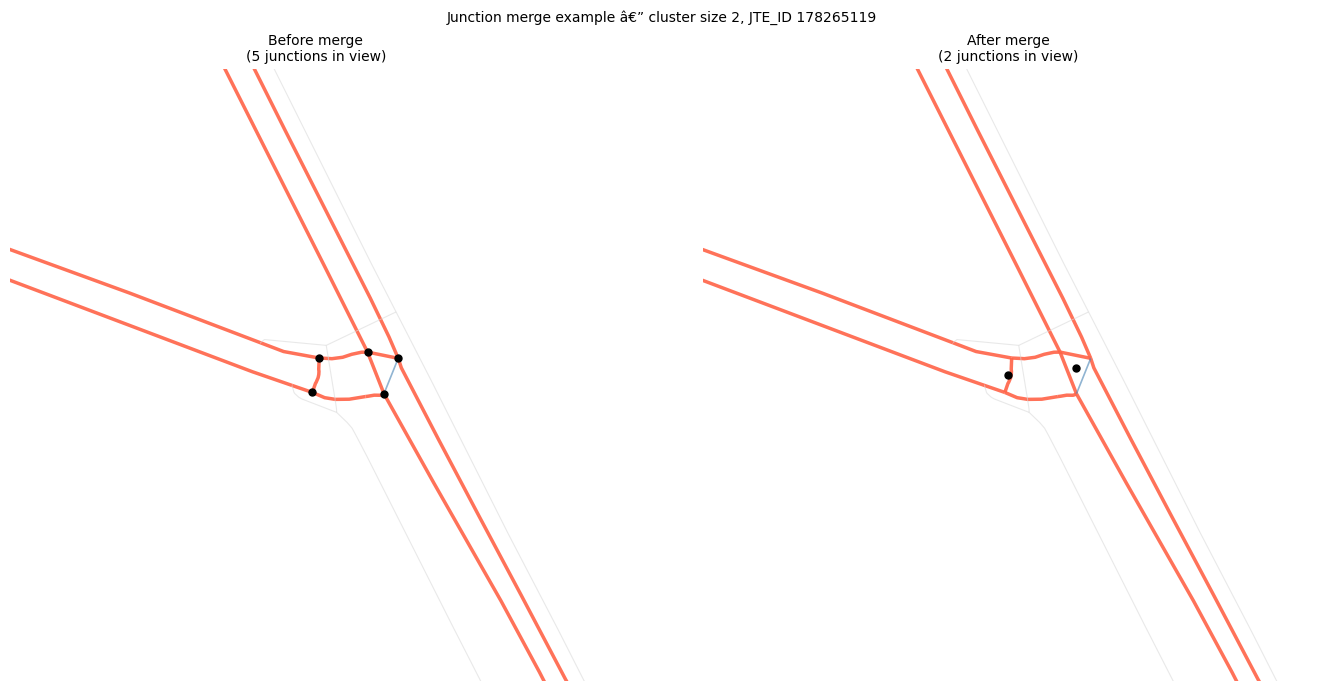

In [13]:
# Before/after figures for three example clusters of decreasing size.

ZOOM_RADIUS = 200  # metres around the example junction

# --- Pick three example clusters at different sizes ---
# Sort components by member count (descending) and pick ranks 0, 25th-percentile, and last.
sorted_labels = multi_labels.sort_values(ascending=False)
n_clusters    = len(sorted_labels)

example_labels = [
    sorted_labels.index[0],                        # largest cluster
    sorted_labels.index[max(1, n_clusters // 4)],  # upper-quarter cluster
    sorted_labels.index[max(2, n_clusters // 2)],  # median-size cluster
]

# Resolve each example label to a canonical JTE_ID and its cluster size
examples = []
for comp_label in example_labels:
    mask       = labels == comp_label
    member_ids = inter_ids[mask]
    canonical  = int(member_ids.min())
    size       = int(mask.sum())
    examples.append((canonical, size))

# Pre-compute FOW column on the gemeente road network (used in all panels)
wvk_viz = wegvakken_gemeente.copy()
wvk_viz["FOW_int"] = pd.to_numeric(wvk_viz["FOW"], errors="coerce")

fow_style = {
    2: ("tomato",    2.5, 0.9),
    3: ("steelblue", 1.2, 0.6),
}

def draw_panel(ax, junctions, wvk_local, title):
    """Draw road network + junction dots onto ax."""
    for fow_val, (color, lw, alpha) in fow_style.items():
        sub = wvk_local[wvk_local["FOW_int"] == fow_val]
        if not sub.empty:
            sub.plot(ax=ax, color=color, linewidth=lw, alpha=alpha)
    other = wvk_local[~wvk_local["FOW_int"].isin(fow_style)]
    if not other.empty:
        other.plot(ax=ax, color="lightgray", linewidth=0.8, alpha=0.5)
    if not junctions.empty:
        junctions.plot(ax=ax, color="black", markersize=25, zorder=5)
    ax.set_title(f"{title}\n({len(junctions)} junctions in view)", fontsize=10)
    ax.set_axis_off()

# --- Produce one before/after figure per example cluster ---
for canonical_id, cluster_size in examples:
    centre_pt = intersections_merged.loc[canonical_id, "geometry"]
    buf       = centre_pt.buffer(ZOOM_RADIUS)

    local_wvk    = wvk_viz[wvk_viz.geometry.intersects(buf)].copy()
    local_before = intersections[intersections.geometry.within(buf)]
    local_after  = intersections_merged[intersections_merged.geometry.within(buf)]

    fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(14, 7))

    draw_panel(ax_before, local_before, local_wvk, "Before merge")
    draw_panel(ax_after,  local_after,  local_wvk, "After merge")

    for ax in (ax_before, ax_after):
        ax.set_xlim(*buf.bounds[::2])
        ax.set_ylim(*buf.bounds[1::2])

    plt.suptitle(
        f"Junction merge example â€” cluster size {cluster_size}, JTE_ID {canonical_id}\n",
        fontsize=10
    )
    plt.tight_layout()
    plt.show()


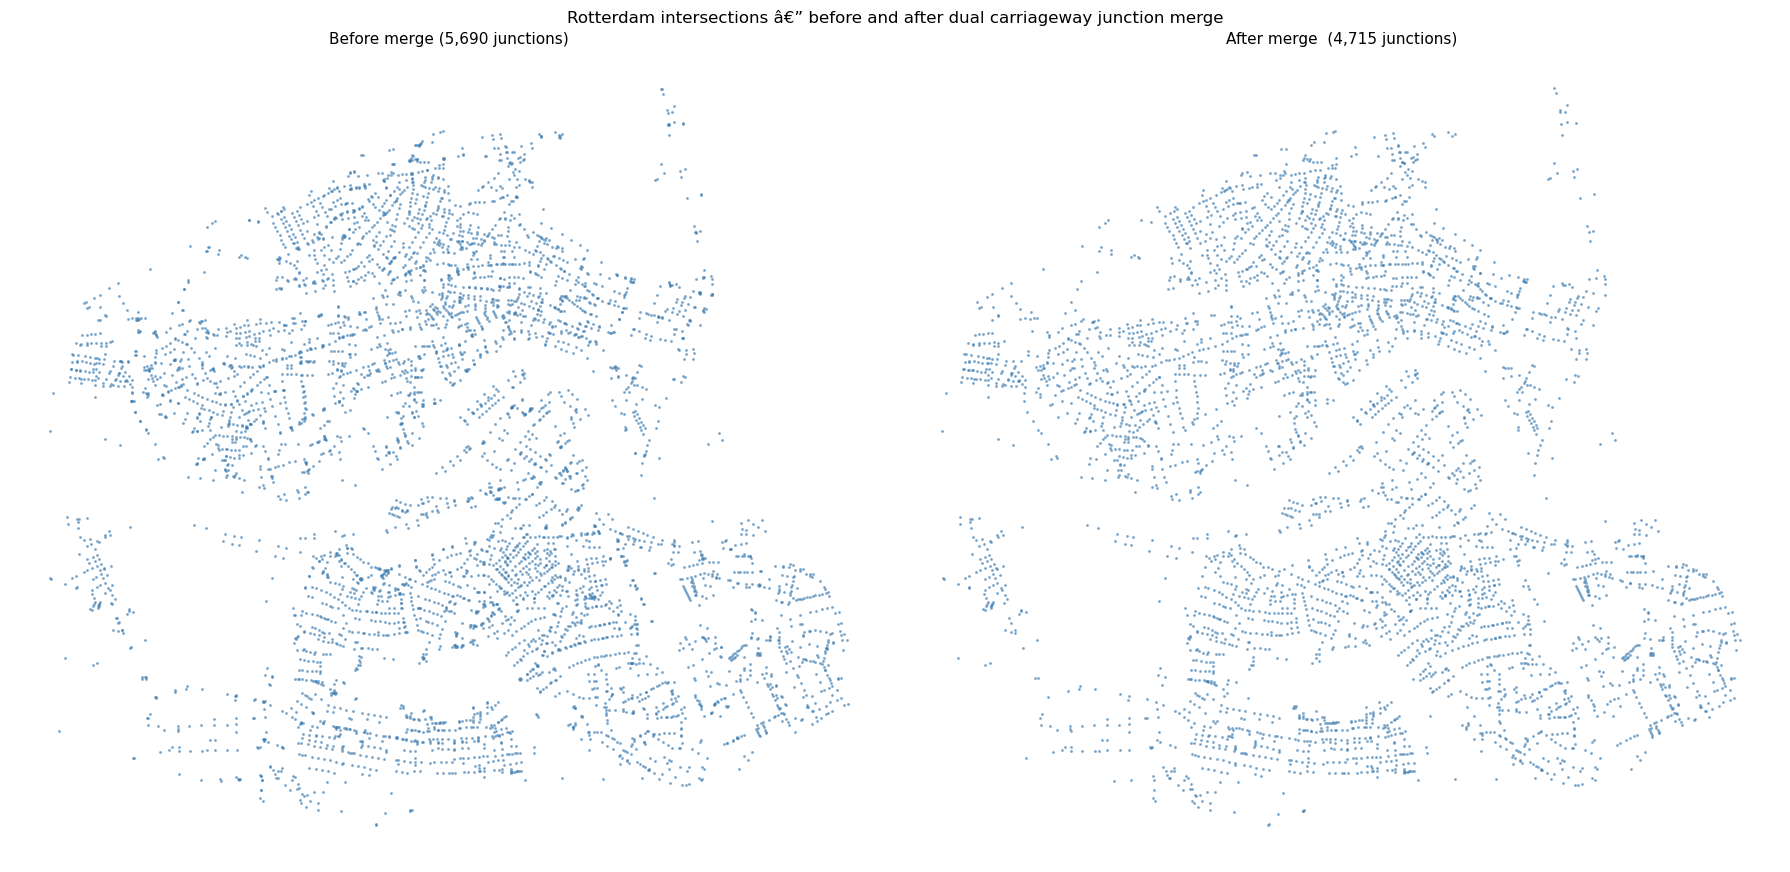

In [14]:
# Full-city map: before vs after
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

for ax, (junctions, title) in zip(axes, [
    (intersections,        f"Before merge ({len(intersections):,} junctions)"),
    (intersections_merged, f"After merge  ({len(intersections_merged):,} junctions)"),
]):
    junctions.plot(ax=ax, color="steelblue", markersize=1.5, alpha=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()

plt.suptitle("Rotterdam intersections â€” before and after dual carriageway junction merge", fontsize=12)
plt.tight_layout()
plt.show()

## 10. Verification 2.0 â€” signal breakdown

How many merges came from each signal?
This section shows the split between FOW=2-driven merges and bayonet-driven merges,
then plots 4 example locations for each signal so you can visually confirm they look correct.

In [15]:
# Build a lookup: canonical JTE_ID â†’ set of original member JTE_IDs (including itself)
# This lets us trace which pairs each merge cluster contains.
cluster_members = {}  # canonical_id â†’ list of all member JTE_IDs in that cluster
for comp_label in multi_labels.index:
    member_mask    = labels == comp_label
    member_jte_ids = inter_ids[member_mask]
    canonical_id   = int(member_jte_ids.min())
    cluster_members[canonical_id] = list(member_jte_ids)

# For each signal, collect the canonical IDs of clusters it triggered.
# A pair (a, b) triggered by signal X means the cluster containing a and b was
# at least partially caused by signal X.
def pairs_to_canonical(pair_set):
    """Given a set of (jte_a, jte_b) pairs, return the canonical IDs of their clusters."""
    canonical_ids = set()
    for a, b in pair_set:
        # Find which cluster each junction ended up in via the remap dict
        canon_a = remap.get(int(a), int(a))
        canon_b = remap.get(int(b), int(b))
        # Both should map to the same canonical â€” add it
        canonical_ids.add(canon_a)
    return canonical_ids

canonical_fow2    = pairs_to_canonical(only_fow2)
canonical_bayonet = pairs_to_canonical(only_bayonet)
canonical_both    = pairs_to_canonical(overlap_pairs)

print("=== Merge signal breakdown ===")
print(f"Clusters triggered by FOW=2 only:     {len(canonical_fow2):,}")
print(f"Clusters triggered by bayonet only:   {len(canonical_bayonet):,}")
print(f"Clusters triggered by both signals:   {len(canonical_both):,}")
print(f"Total merge clusters:                 {len(multi_labels):,}")

=== Merge signal breakdown ===
Clusters triggered by FOW=2 only:     561
Clusters triggered by bayonet only:   18
Clusters triggered by both signals:   42
Total merge clusters:                 600


### FOW=2 examples

4 clusters that were merged because of the dual-carriageway signal (FOW=2, 30m threshold).
Red roads = FOW=2 (dual carriageway), blue = FOW=3 (single carriageway).
Left panel = original duplicate junction dots; right panel = single merged dot.

In [16]:
def plot_merge_examples(canonical_ids, title, zoom_radius=120, n_examples=4):
    """
    Plot before/after merge figures for the n_examples largest clusters
    from the given list of canonical JTE_IDs.

    Relies on draw_panel, wvk_viz, intersections, intersections_merged,
    and cluster_members â€” all defined in earlier cells.
    """
    # Sort candidate canonical IDs by cluster size (descending) and take the top n
    sized = [
        (cid, len(cluster_members.get(cid, [cid])))
        for cid in canonical_ids
        if cid in intersections_merged.index
    ]
    sized.sort(key=lambda x: -x[1])
    examples = sized[:n_examples]

    print(f"{title}")
    print(f"Showing {len(examples)} largest clusters out of {len(canonical_ids)} total.")

    for canonical_id, cluster_size in examples:
        centre_pt = intersections_merged.loc[canonical_id, "geometry"]
        buf       = centre_pt.buffer(zoom_radius)

        # Clip road network and intersection points to the viewport buffer
        local_wvk    = wvk_viz[wvk_viz.geometry.intersects(buf)].copy()
        local_before = intersections[intersections.geometry.within(buf)]
        local_after  = intersections_merged[intersections_merged.geometry.within(buf)]

        fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(14, 7))
        draw_panel(ax_before, local_before, local_wvk, "Before merge")
        draw_panel(ax_after,  local_after,  local_wvk, "After merge")

        # Lock both panels to the same viewport
        for ax in (ax_before, ax_after):
            ax.set_xlim(*buf.bounds[::2])
            ax.set_ylim(*buf.bounds[1::2])

        plt.suptitle(
            f"{title}\n"
            f"Cluster size {cluster_size}, canonical JTE_ID {canonical_id}\n"
            f"Red = FOW=2 (dual carriageway), Blue = FOW=3 (single), Black dots = intersections\n",
            fontsize=10,
        )
        plt.tight_layout()
        plt.show()


FOW=2 signal â€” dual carriageway junction merges (4 largest clusters)
Showing 4 largest clusters out of 561 total.


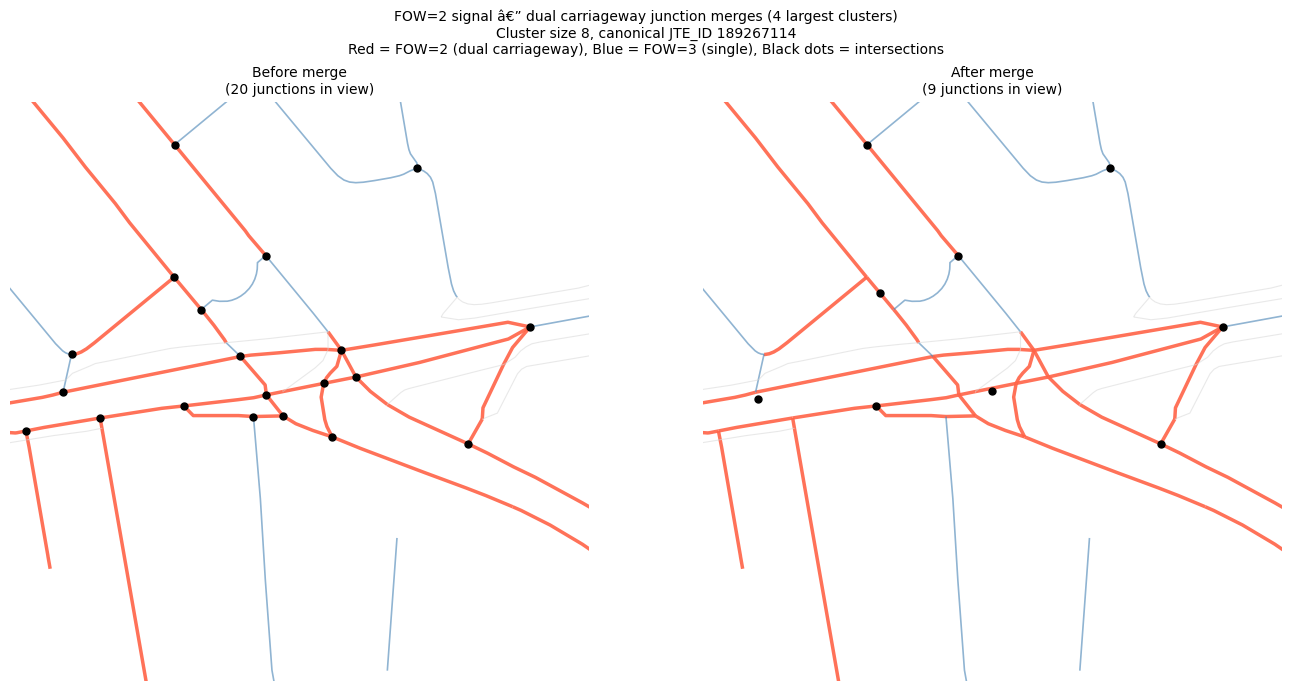

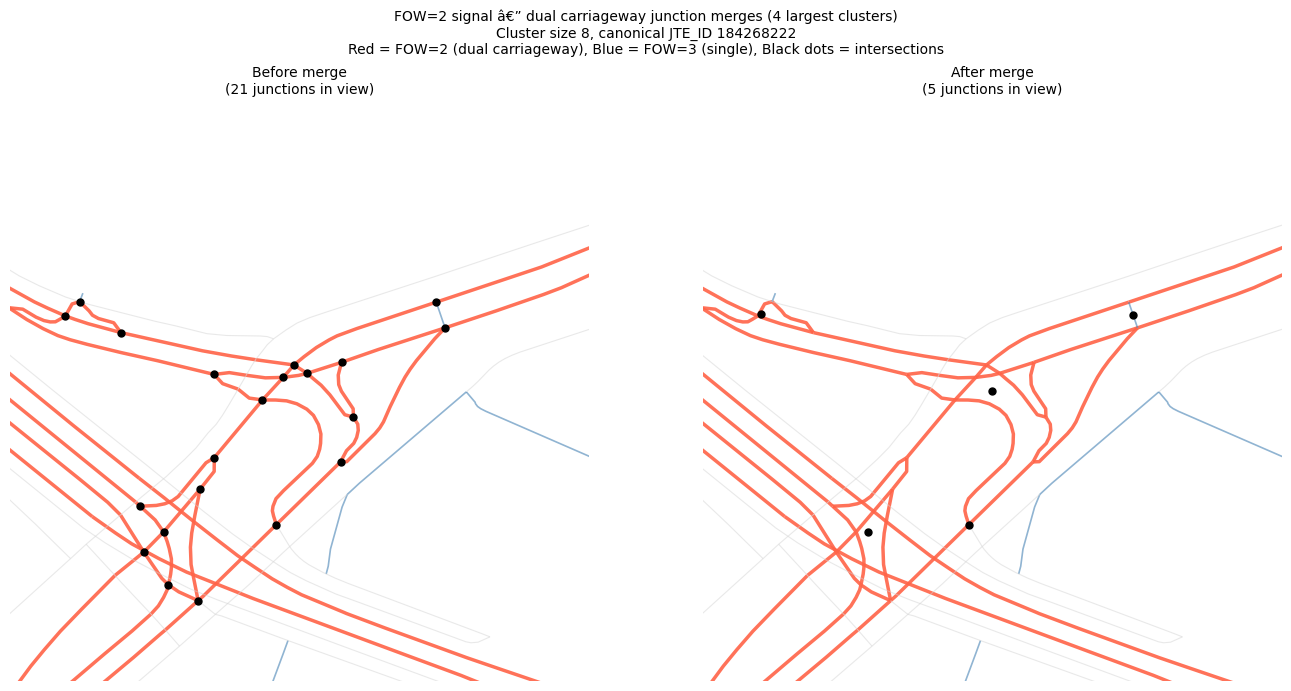

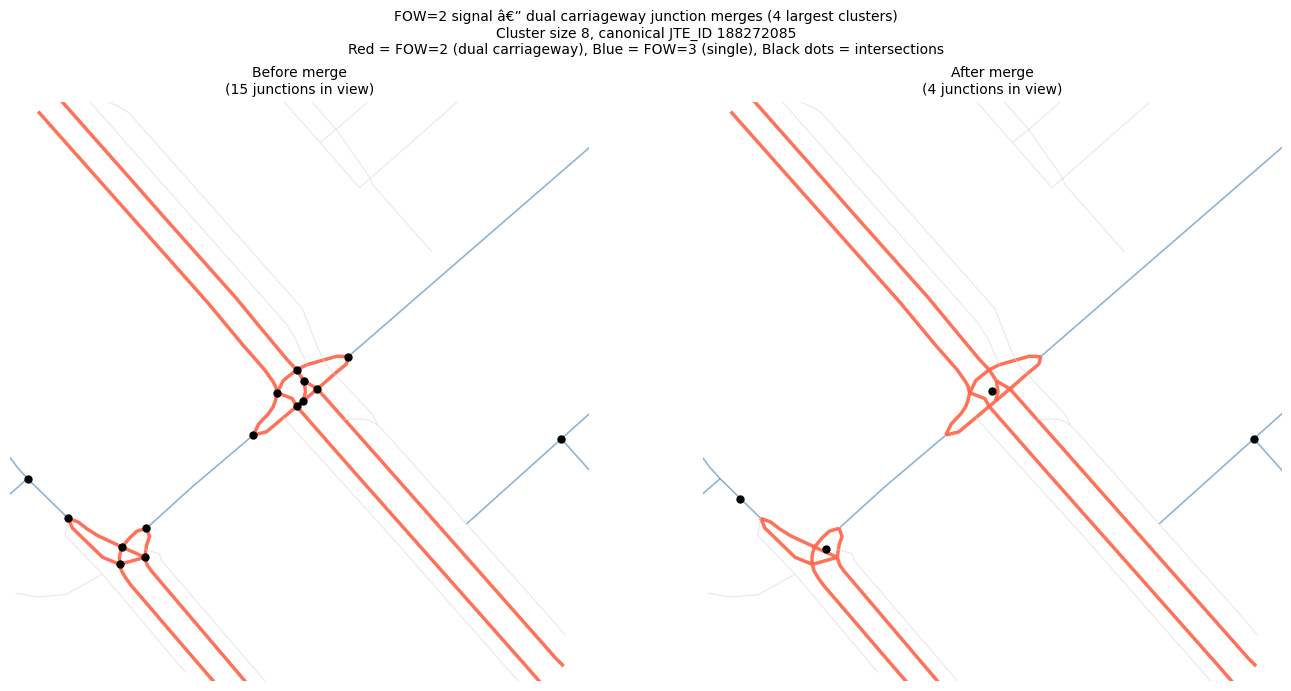

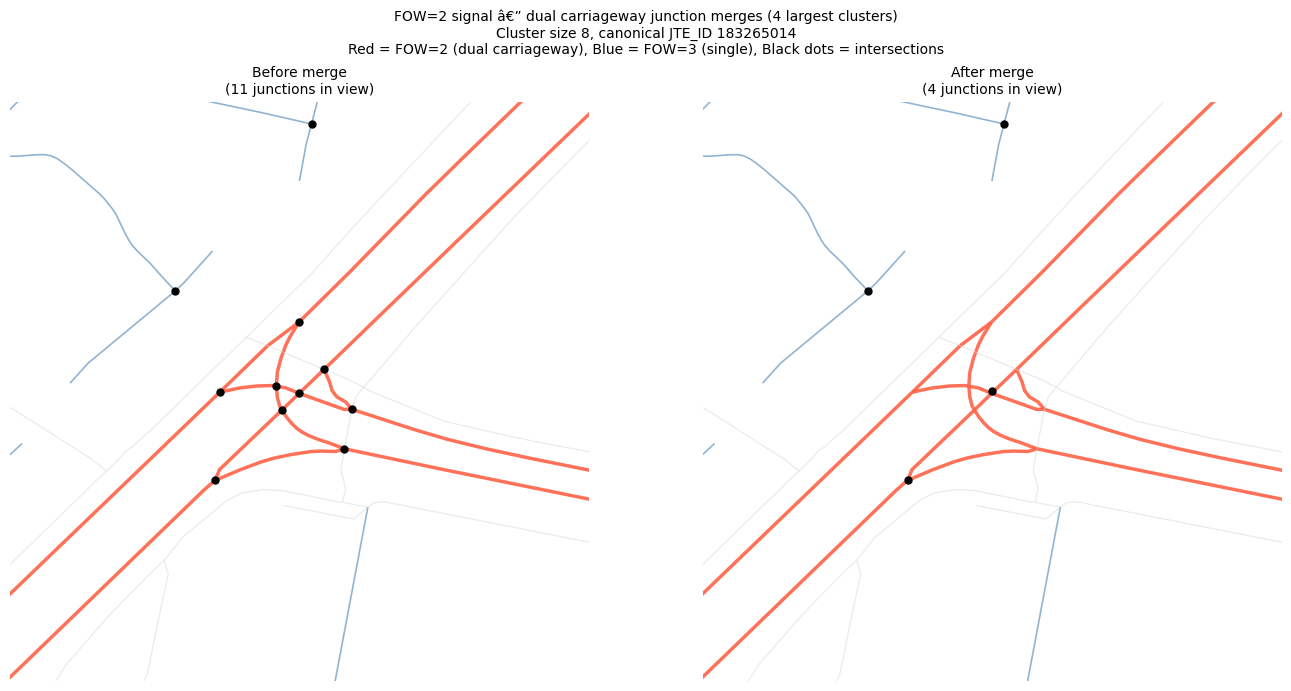

In [17]:
plot_merge_examples(
    list(canonical_fow2),
    title="FOW=2 signal â€” dual carriageway junction merges (4 largest clusters)",
    zoom_radius=120,
)

### Bayonet examples

4 clusters that were merged *only* because of the tight proximity signal (â‰¤6m, no FOW filter).
These are the bayonet intersections: single-carriageway junctions digitised as two near-identical points.
Use the zoom to verify the two original dots are on top of each other â€” if they look clearly separate, the threshold may be too high.

Bayonet signal â€” tight proximity junction merges
Showing 4 largest clusters out of 18 total.


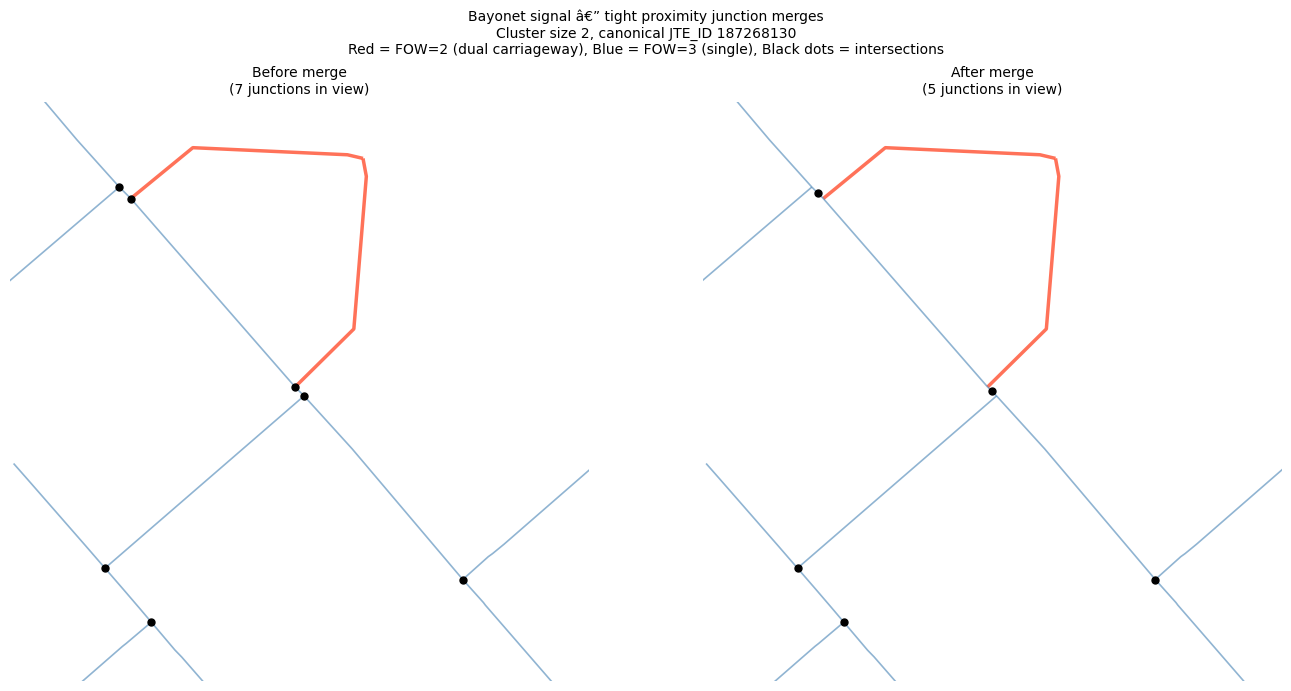

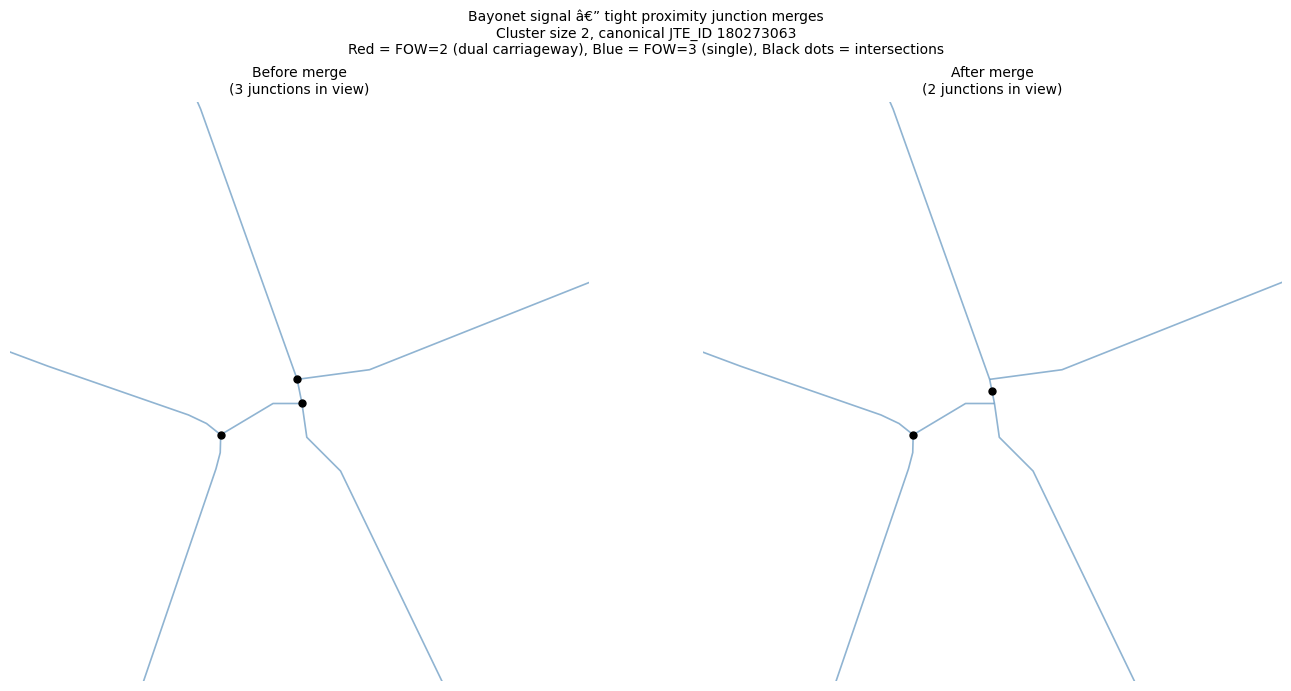

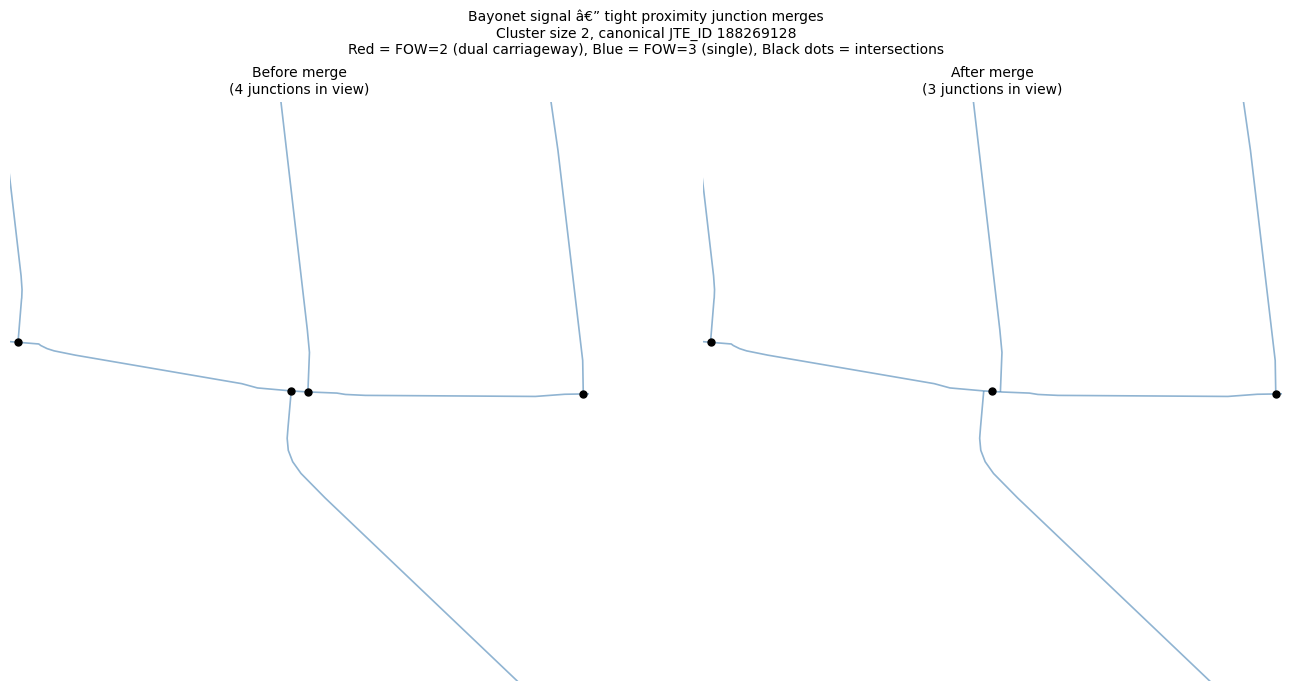

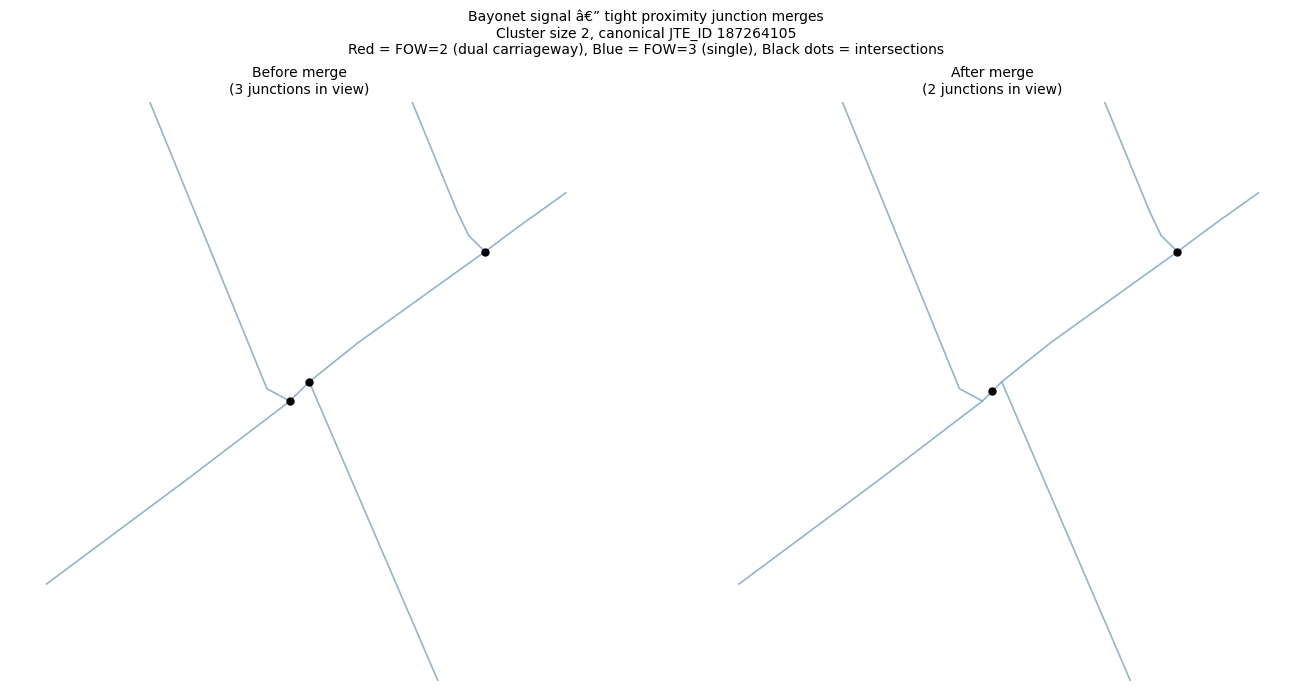

In [18]:
plot_merge_examples(
    list(canonical_bayonet),
    title="Bayonet signal â€” tight proximity junction merges",
    zoom_radius=60,  # smaller zoom â€” these pairs are very close together
)